# **Проєкт: «Оптимізація інвестиційного портфеля за моделлю Марковіца»**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **ВИХІДНІ ДАНІ**

На цьому етапі було завантажено історичні дані щодо цін активів за обраний період з використанням бібліотеки yfinance. Отримані дані являють собою часовий ряд цін активів, який використовується для:

*   розрахунку дохідностей
*  оцінки ризику

*   побудови портфелів










In [ ]:
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

tickers = ["AAPL", "MSFT", "GOOGL",  "AMZN", "NVDA", "META", "TSLA","JPM","XOM", "KO","BTC-USD","GLD"]
data = yf.download(tickers, start="2016-01-01", end="2026-01-01",progress=False)
stock_prices = data["Close"].ffill().dropna().reset_index()

stock_prices

Ticker,Date,AAPL,AMZN,BTC-USD,GLD,GOOGL,JPM,KO,META,MSFT,NVDA,TSLA,XOM
0,2016-01-04,23.730946,31.849501,433.091003,102.889999,37.660736,48.401146,30.753256,101.424088,47.874180,0.789545,14.894000,49.654362
1,2016-01-05,23.136263,31.689501,431.959991,103.180000,37.764381,48.484825,30.862043,101.930107,48.092598,0.802228,14.895333,50.077457
2,2016-01-06,22.683495,31.632500,429.105011,104.669998,37.655281,47.784908,30.695225,102.168236,47.218983,0.769057,14.602667,49.660767
3,2016-01-07,21.726147,30.396999,458.048004,106.150002,36.746292,45.852509,30.187496,97.157555,45.576576,0.738567,14.376667,48.865906
4,2016-01-08,21.841030,30.352501,453.230011,105.680000,36.245930,44.825447,30.107714,96.572159,45.716366,0.722713,14.066667,47.878723
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3645,2025-12-27,273.144409,232.520004,87802.156250,416.739990,313.289459,324.775421,69.392860,662.722595,486.599365,190.519684,475.190002,118.321342
3646,2025-12-28,273.144409,232.520004,87835.835938,416.739990,313.289459,324.775421,69.392860,662.722595,486.599365,190.519684,475.190002,118.321342
3647,2025-12-29,273.504089,232.070007,87138.140625,398.600006,313.339417,320.655182,69.680878,658.126526,485.990753,188.209808,459.640015,119.731941
3648,2025-12-30,272.824707,232.529999,88430.132812,398.890015,313.629242,320.328369,69.591492,665.380310,486.369904,187.529846,454.429993,120.188896


Для подальших розрахунків (дохідності, ризику, коваріації) використовуються лише числові дані. Стовпець із датами не бере участі в математичних операціях, тому його видалення спрощує обробку даних.

In [ ]:
stock_prices_drop_date = stock_prices.drop(columns=['Date'])
stock_prices_drop_date

Ticker,AAPL,AMZN,BTC-USD,GLD,GOOGL,JPM,KO,META,MSFT,NVDA,TSLA,XOM
0,23.730946,31.849501,433.091003,102.889999,37.660736,48.401146,30.753256,101.424088,47.874180,0.789545,14.894000,49.654362
1,23.136263,31.689501,431.959991,103.180000,37.764381,48.484825,30.862043,101.930107,48.092598,0.802228,14.895333,50.077457
2,22.683495,31.632500,429.105011,104.669998,37.655281,47.784908,30.695225,102.168236,47.218983,0.769057,14.602667,49.660767
3,21.726147,30.396999,458.048004,106.150002,36.746292,45.852509,30.187496,97.157555,45.576576,0.738567,14.376667,48.865906
4,21.841030,30.352501,453.230011,105.680000,36.245930,44.825447,30.107714,96.572159,45.716366,0.722713,14.066667,47.878723
...,...,...,...,...,...,...,...,...,...,...,...,...
3645,273.144409,232.520004,87802.156250,416.739990,313.289459,324.775421,69.392860,662.722595,486.599365,190.519684,475.190002,118.321342
3646,273.144409,232.520004,87835.835938,416.739990,313.289459,324.775421,69.392860,662.722595,486.599365,190.519684,475.190002,118.321342
3647,273.504089,232.070007,87138.140625,398.600006,313.339417,320.655182,69.680878,658.126526,485.990753,188.209808,459.640015,119.731941
3648,272.824707,232.529999,88430.132812,398.890015,313.629242,320.328369,69.591492,665.380310,486.369904,187.529846,454.429993,120.188896


# **ПОБУДОВА ГРАФІКА ЦІН АКТИВУ**

На цьому етапі було побудовано графік зміни ціни обраного активу за тривалий період часу.
Графік дозволяє:

*   побачити загальний тренд активу
*   визначити періоди зростання та падіння

*   оцінити діапазон коливань ціни








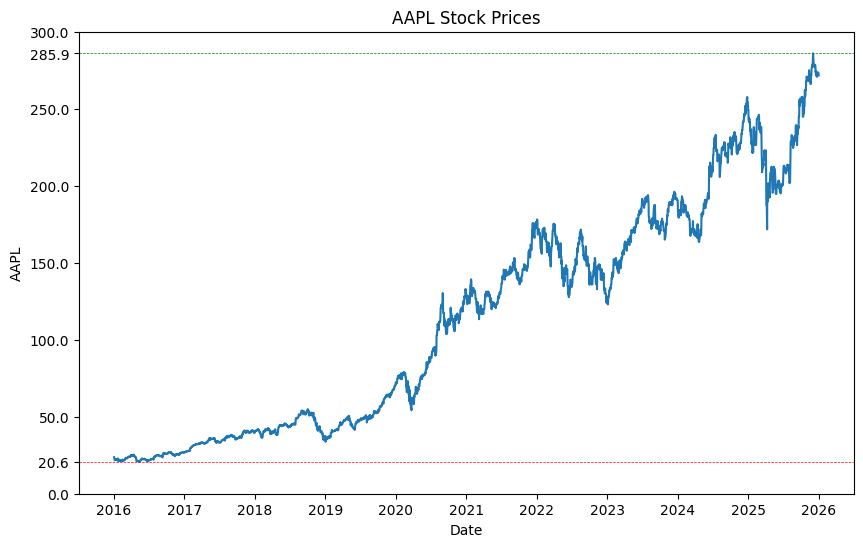

In [ ]:
asset = 'AAPL'

plt.figure(figsize=(10,6))
sns.lineplot(x='Date',y= asset,data=stock_prices)

min_val = stock_prices[asset].min()
max_val = stock_prices[asset].max()

plt.axhline(min_val,color='red',linestyle='--',linewidth='0.5')
plt.axhline(max_val,color='green',linestyle='--',linewidth='0.5')
plt.title(f"{asset} Stock Prices")
yticks = list(plt.yticks()[0])
yticks.extend([min_val,max_val])
plt.yticks(sorted(yticks))


plt.show()

# **РОЗРАХУНОК ДОХІДНОСТІ АКТИВІВ**

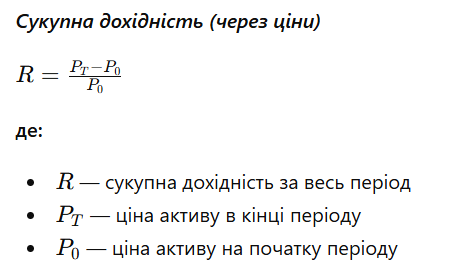

На цьому етапі було розраховано денні дохідності активів на основі історичних цін.

Дохідності є основою для подальших розрахунків:

*   очікуваної дохідності портфеля
*   ризику (волатильності)

*   коваріаційної матриці







In [ ]:
returns = stock_prices_drop_date.pct_change().dropna()
returns


Ticker,AAPL,AMZN,BTC-USD,GLD,GOOGL,JPM,KO,META,MSFT,NVDA,TSLA,XOM
1,-0.025059,-0.005024,-0.002611,0.002819,0.002752,0.001729,0.003537,0.004989,0.004562,0.016064,0.000090,0.008521
2,-0.019570,-0.001799,-0.006609,0.014441,-0.002889,-0.014436,-0.005405,0.002336,-0.018165,-0.041350,-0.019648,-0.008321
3,-0.042205,-0.039058,0.067450,0.014140,-0.024140,-0.040440,-0.016541,-0.049043,-0.034783,-0.039645,-0.015477,-0.016006
4,0.005288,-0.001464,-0.010519,-0.004428,-0.013617,-0.022399,-0.002643,-0.006025,0.003067,-0.021466,-0.021563,-0.020202
5,0.000000,0.000000,-0.012398,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
3645,0.000000,0.000000,0.005736,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3646,0.000000,0.000000,0.000384,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3647,0.001317,-0.001935,-0.007943,-0.043528,0.000159,-0.012686,0.004151,-0.006935,-0.001251,-0.012124,-0.032724,0.011922
3648,-0.002484,0.001982,0.014827,0.000728,0.000925,-0.001019,-0.001283,0.011022,0.000780,-0.003613,-0.011335,0.003816


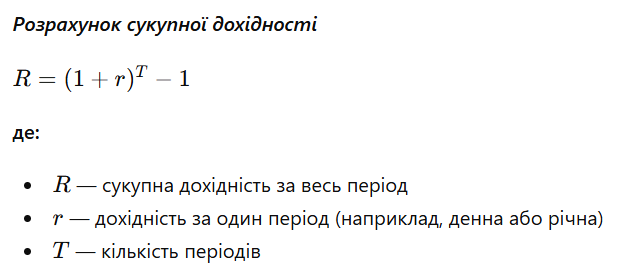

На цьому етапі було розраховано загальну дохідність кожного активу за весь період із використанням складного відсотка.

In [ ]:
total_return = ((1 + returns).prod() - 1).reset_index().rename(columns={0:'Total_Return'})
total_return

,Ticker,Total_Return
0,AAPL,10.445218
1,AMZN,6.247210
2,BTC-USD,201.056444
3,GLD,2.851783
4,GOOGL,7.305197
5,JPM,5.593641
6,KO,1.257731
7,META,5.502650
8,MSFT,9.078892
9,NVDA,235.199221


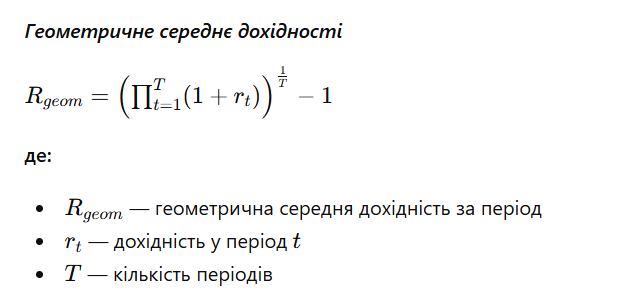

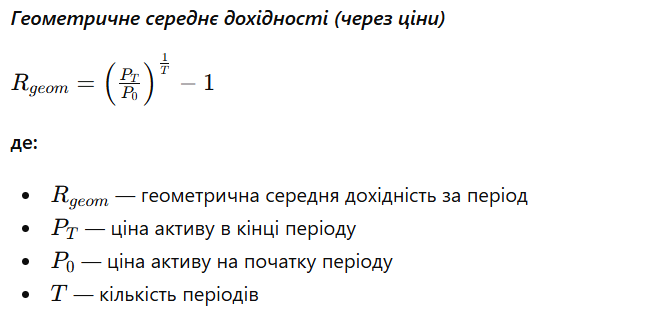

На цьому етапі було розраховано середню дохідність активів з урахуванням складного відсотка.

Геометричне середнє враховує ефект складного відсотка та показує реальну середню дохідність інвестицій.

Геометрична дохідність дає більш точну оцінку реальної дохідності інвестицій порівняно з простим середнім.

In [ ]:
expected_return = (((1 + returns).prod(axis=0))**(1/len(returns))-1).reset_index().rename(columns={0:'Daily_Expected_Return'})
expected_return['Weekly_Expected_Return'] = (1 + expected_return['Daily_Expected_Return'])**7 - 1
expected_return['Monthly_Expected_Return'] = (1 + expected_return['Daily_Expected_Return'])**30 - 1
expected_return['Annual_Expected_Return'] = (1 + expected_return['Daily_Expected_Return'])**365 - 1
expected_return

,Ticker,Daily_Expected_Return,Weekly_Expected_Return,Monthly_Expected_Return,Annual_Expected_Return
0,AAPL,0.000668,0.004687,0.020242,0.276120
1,AMZN,0.000543,0.003807,0.016417,0.219104
2,BTC-USD,0.001456,0.010236,0.044610,0.700632
3,GLD,0.000370,0.002590,0.011149,0.144412
4,GOOGL,0.000580,0.004069,0.017556,0.235834
5,JPM,0.000517,0.003625,0.015627,0.207633
6,KO,0.000223,0.001563,0.006718,0.084868
7,META,0.000513,0.003598,0.015511,0.205956
8,MSFT,0.000633,0.004442,0.019177,0.259995
9,NVDA,0.001499,0.010538,0.045952,0.727400


На етапі перевірки середні денні дохідності було переведено в річні, а річні — у сукупні за 10 років. Результати збіглися.

In [ ]:
proverka_daily_to_annual = (1 + expected_return['Daily_Expected_Return'])**365 - 1
proverka_daily_to_annual = proverka_daily_to_annual.reset_index().rename(columns={'Daily_Expected_Return':'Annual_Return'}).drop(columns='index')

proverka_annual_to_10_years = (1 + expected_return['Annual_Expected_Return'])**10 - 1
proverka_annual_to_10_years = proverka_annual_to_10_years.reset_index().rename(columns={'Annual_Expected_Return':'Total_Return'}).drop(columns='index')

result_proverka = pd.concat([proverka_daily_to_annual, proverka_annual_to_10_years],axis=1)
result_proverka

,Annual_Return,Total_Return
0,0.276120,10.452866
1,0.219104,6.251144
2,0.700632,201.350609
3,0.144412,2.853207
4,0.235834,7.310016
5,0.207633,5.597050
6,0.084868,1.258235
7,0.205956,5.505987
8,0.259995,9.085275
9,0.727400,235.553214


# **РОЗРАХУНОК РИЗИКУ АКТИВІВ**

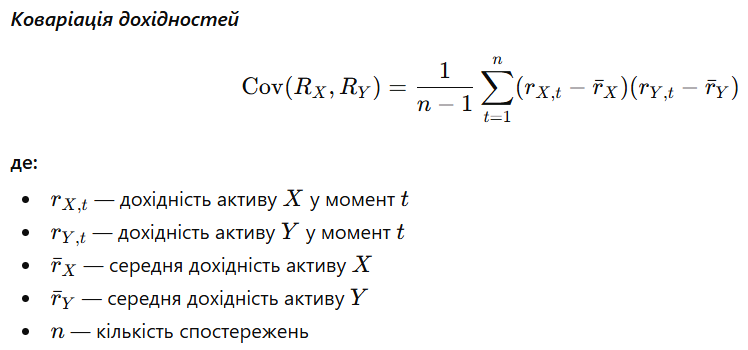

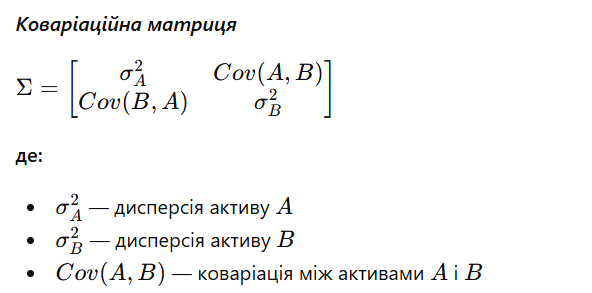

Коваріація показує напрям руху активів:

*   (>)0 → активи рухаються разом
*   (<)0 → рухаються в різні сторони

*   (≈)0 → не пов’язані










Матриця показує:

*   ризик кожного активу (на діагоналі)
*   взаємозв’язок між активами (поза діагоналлю)



In [ ]:
cov_mat = returns.cov()
cov_mat

Ticker,AAPL,AMZN,BTC-USD,GLD,GOOGL,JPM,KO,META,MSFT,NVDA,TSLA,XOM
Ticker,,,,,,,,,,,,
AAPL,0.000231,0.000150,0.000092,0.000004,0.000140,0.000091,0.000048,0.000160,0.000144,0.000213,0.000208,0.000067
AMZN,0.000150,0.000294,0.000103,0.000005,0.000165,0.000076,0.000028,0.000210,0.000160,0.000242,0.000218,0.000045
BTC-USD,0.000092,0.000103,0.001236,0.000026,0.000097,0.000071,0.000020,0.000107,0.000098,0.000174,0.000185,0.000056
GLD,0.000004,0.000005,0.000026,0.000060,0.000006,-0.000010,0.000005,0.000004,0.000003,0.000005,0.000009,0.000005
GOOGL,0.000140,0.000165,0.000097,0.000006,0.000227,0.000088,0.000041,0.000186,0.000149,0.000213,0.000183,0.000058
JPM,0.000091,0.000076,0.000071,-0.000010,0.000088,0.000208,0.000056,0.000092,0.000088,0.000126,0.000124,0.000112
KO,0.000048,0.000028,0.000020,0.000005,0.000041,0.000056,0.000089,0.000033,0.000047,0.000036,0.000037,0.000050
META,0.000160,0.000210,0.000107,0.000004,0.000186,0.000092,0.000033,0.000406,0.000169,0.000259,0.000210,0.000053
MSFT,0.000144,0.000160,0.000098,0.000003,0.000149,0.000088,0.000047,0.000169,0.000196,0.000226,0.000180,0.000054


Проводимо розрахунок аналізу ризику активів. Було розраховано дисперсію (розкид дохідностей) та стандартне відхилення (волатильність денної дохідності).

In [ ]:
val_vol_returns = pd.DataFrame({'Daily_Variance_Returns':returns.var(),'Daily_Volatility_Returns':returns.std()})
val_vol_returns = val_vol_returns.reset_index()
val_vol_returns

,Ticker,Daily_Variance_Returns,Daily_Volatility_Returns
0,AAPL,0.000231,0.015195
1,AMZN,0.000294,0.017152
2,BTC-USD,0.001236,0.035158
3,GLD,0.000060,0.007742
4,GOOGL,0.000227,0.015079
5,JPM,0.000208,0.014423
6,KO,0.000089,0.009443
7,META,0.000406,0.020139
8,MSFT,0.000196,0.013995
9,NVDA,0.000682,0.026111


# **РОЗРАХУНОК РИЗИКУ, ДОХІДНОСТІ ТА КОЕФІЦІЄНТА ШАРПА ДЛЯ РІВНОЗВАЖЕНОГО ПОРТФЕЛЯ**

На цьому етапі було розраховано ваги активів для рівнозваженого портфеля.
Кожному активу надається однакова вага:

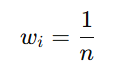

Таким чином, було отримано базовий набір ваг, за якого капітал рівномірно розподілений між усіма активами.

In [ ]:
n = len(total_return['Total_Return'])
weights = np.ones(n) / n
print(weights)

[0.08333333 0.08333333 0.08333333 0.08333333 0.08333333 0.08333333
 0.08333333 0.08333333 0.08333333 0.08333333 0.08333333 0.08333333]


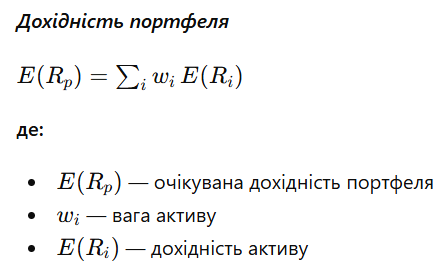

**Дохідність портфеля** визначається як зважена сума дохідностей усіх активів, що входять до його складу. Дохідність портфеля залежить не лише від окремих активів, а й від їхніх ваг. Для аналізу портфеля дохідність, розрахована на денній основі, переводиться в **річну з урахуванням складного відсотка**.

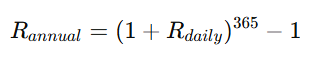

In [ ]:
portfolio_return = np.dot(weights, expected_return['Daily_Expected_Return'])
print(f"Daily Equal Weight Portfolio Return = {portfolio_return:.4f}")

annual_portfolio_return =(1+portfolio_return)**365 - 1
print(f"Annual Equal Weight Portfolio Return = {annual_portfolio_return:.4f}")

Daily Equal Weight Portfolio Return = 0.0007
Annual Equal Weight Portfolio Return = 0.2823


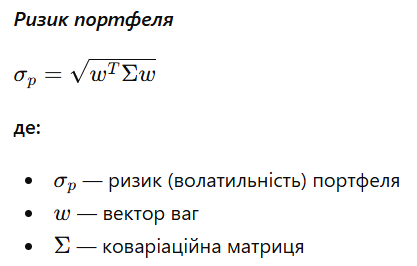

**Ризик (волатильність) портфеля** розраховується з використанням **коваріаційної матриці активів та їхніх ваг**. Ризик портфеля залежить не лише від окремих активів, а й від їхньої взаємної кореляції. **Диверсифікація** дозволяє знижувати ризик портфеля за рахунок поєднання активів із різною динамікою дохідності. Для коректного аналізу портфеля ризик, розрахований на денній основі, переводиться в** річний показник**.

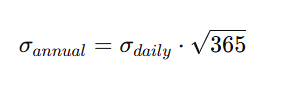

In [ ]:
portfolio_risk = np.sqrt(np.dot(weights.T,np.dot(cov_mat,weights)))
print(f"Daily Equal Weight Portfolio Risk = {portfolio_risk:.4f}")
annual_portfolio_risk = portfolio_risk*np.sqrt(365)
print(f"Annual Equal Weight Portfolio Risk = {annual_portfolio_risk:.4f}")

Daily Equal Weight Portfolio Risk = 0.0113
Annual Equal Weight Portfolio Risk = 0.2159


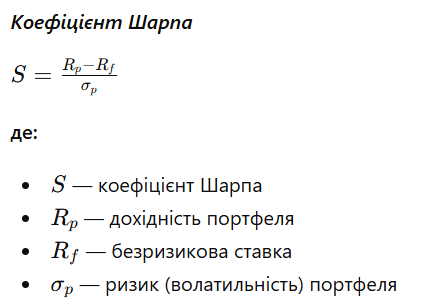

**Коефіцієнт Sharpe Ratio** використовується для оцінки ефективності інвестиційного портфеля з урахуванням ризику. Він показує, скільки додаткової дохідності інвестор отримує на кожну одиницю ризику. Різниця
(𝑅𝑝 − 𝑅𝑓) показує, наскільки портфель випереджає безризиковий актив.

Sharpe Ratio < 1 — слабкий портфель,
Sharpe Ratio 1–2 — хороший портфель,
Sharpe Ratio > 2 — відмінний портфель.

**Безризикова ставка (Risk-Free Rate)**— це дохідність активу, який вважається практично вільним від ризику. Вона використовується як базовий орієнтир для порівняння ефективності інвестиційного портфеля.

На практиці абсолютно безризикових активів не існує, але використовуються максимально надійні інструменти. Як безризикову ставку зазвичай беруть **державні облігації (T-Bills)** з дохідністю 2%–3% річних.

In [ ]:
rf = 0.02
sharpe_ratio = (annual_portfolio_return - rf)/annual_portfolio_risk
print(f"Sharpe Ratio Equal Weight Portfolio = {sharpe_ratio:.4f}")

Sharpe Ratio Equal Weight Portfolio = 1.2152


**РІВНОЗВАЖЕНИЙ ПОРТФЕЛЬ**

На цьому етапі було побудовано рівнозважений портфель, у якому кожному активу надається однакова вага. **Рівнозважений портфель слугує відправною точкою аналізу, але не є оптимальним**, і для досягнення найкращих результатів необхідно варіювати ваги активів та шукати найбільш ефективні комбінації. Змінюючи ваги активів, інвестор може керувати очікуваною дохідністю портфеля та адаптувати його під свої цілі.

In [ ]:
print(f"Annual Equal Weight Portfolio Return = {annual_portfolio_return:.4f}")
print(f"Annual Equal Weight Portfolio Risk = {annual_portfolio_risk:.4f}")
print(f"Sharpe Ratio Equal Weight Portfolio = {sharpe_ratio:.4f}")

weights_ticker_equal_weight = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': weights,
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_equal_weight


Annual Equal Weight Portfolio Return = 0.2823
Annual Equal Weight Portfolio Risk = 0.2159
Sharpe Ratio Equal Weight Portfolio = 1.2152


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.083333,0.000668,0.015195,0.276120
1,AMZN,0.083333,0.000543,0.017152,0.219104
2,BTC-USD,0.083333,0.001456,0.035158,0.700632
3,GLD,0.083333,0.000370,0.007742,0.144412
4,GOOGL,0.083333,0.000580,0.015079,0.235834
5,JPM,0.083333,0.000517,0.014423,0.207633
6,KO,0.083333,0.000223,0.009443,0.084868
7,META,0.083333,0.000513,0.020139,0.205956
8,MSFT,0.083333,0.000633,0.013995,0.259995
9,NVDA,0.083333,0.001499,0.026111,0.727400


# **ГЕНЕРАЦІЯ ВИПАДКОВИХ ПОРТФЕЛІВ**

У цьому блоці коду виконується генерація випадкових портфелів з урахуванням заданих обмежень (min_w,
max_w) на ваги активів. Це забезпечує диверсифікацію та виключає надмірну концентрацію капіталу.

Розраховуються **денні ризик і дохідність портфелів**, після чого вони переводяться в річні значення. Також зберігаються **річний коефіцієнт Шарпа та ваги портфелів.**

In [ ]:
num_portfolios = 1000000

results = []

min_w = 0.02
max_w = 0.25
while len(results) < num_portfolios:
  weight = np.random.random(n)
  weight /= np.sum(weight)
  if np.any(weight < min_w) or np.any(weight > max_w):
    continue

  ret = np.dot(weight, expected_return['Daily_Expected_Return'])
  annual_ret = (1 + ret)**365 - 1
  risk = np.sqrt(np.dot(weight.T, np.dot(cov_mat, weight)))
  annual_risk = risk * np.sqrt(365)
  sharpe = (annual_ret - rf)/annual_risk
  results.append((annual_ret, annual_risk, sharpe, weight))



In [ ]:
df_results = pd.DataFrame(results, columns=['Return', 'Risk', 'Sharpe', 'Weights'])
df_results["Return"] = df_results["Return"].round(4)
df_results["Risk"] = df_results["Risk"].round(4)
df_results["Sharpe"] = df_results["Sharpe"].round(4)
df_results["Weights"] = df_results["Weights"].round(2)

df_results['Risk'].count()
df_results

,Return,Risk,Sharpe,Weights
0,0.3001,0.2247,1.2463,"[0.06977537025646349, 0.09020516616890219, 0.1..."
1,0.2855,0.2244,1.1833,"[0.10349597309967958, 0.042599317742186275, 0...."
2,0.2806,0.2240,1.1634,"[0.04232117175012969, 0.06218311235229265, 0.1..."
3,0.3151,0.2303,1.2812,"[0.09217261887437664, 0.0589416981253837, 0.11..."
4,0.3111,0.2396,1.2148,"[0.16291356659985723, 0.04223574011639558, 0.0..."
...,...,...,...,...
999995,0.3107,0.2486,1.1695,"[0.14686600266132044, 0.06854428122324921, 0.0..."
999996,0.2388,0.1875,1.1667,"[0.04175593909609262, 0.11439842261170263, 0.0..."
999997,0.3322,0.2481,1.2586,"[0.07992312004418518, 0.09540301012723544, 0.1..."
999998,0.2400,0.2044,1.0763,"[0.05492788461210525, 0.08537631065177535, 0.0..."


Після генерації випадкових портфелів було проведено описову статистику (max–min) ключових показників: **дохідності (Return), ризику (Risk) та коефіцієнта Шарпа.**

In [ ]:
df_results.describe()

,Return,Risk,Sharpe
count,1000000.000000,1000000.000000,1000000.000000
mean,0.282572,0.219724,1.194100
std,0.025914,0.014914,0.071785
min,0.186500,0.154500,0.865600
25%,0.264700,0.209600,1.146400
50%,0.282100,0.219400,1.196800
75%,0.299800,0.229500,1.244400
max,0.440700,0.307500,1.482500


# **ПОБУДОВА ЕФЕКТИВНОЇ ГРАНИЦІ (EFFICIENT FRONTIER)**

У цьому блоці коду здійснюється **побудова ефективної границі** на основі раніше згенерованих портфелів. **Ефективна границя** являє собою множину портфелів, які забезпечують **максимальну дохідність при заданому рівні ризику**.

Алгоритм працює таким чином:

Ми проходимо по портфелях у порядку зростання ризику. Для кожного портфеля перевіряємо, чи є його дохідність вищою за всі попередні. Якщо так — додаємо його до ефективної границі.

Таким чином залишаються лише ті портфелі, які забезпечують максимальну дохідність при відповідному рівні ризику.

In [ ]:
df_results_sort_risk  =  df_results.sort_values('Risk')
frontier = []
max_return = -np.inf

for _, row in df_results_sort_risk.iterrows():
    if row['Return'] > max_return:
        frontier.append(row)
        max_return = row['Return']

frontier = pd.DataFrame(frontier)
frontier

,Return,Risk,Sharpe,Weights
188998,0.2167,0.1545,1.2734,"[0.034349714384322466, 0.028252951539320285, 0..."
459247,0.2281,0.1613,1.2900,"[0.021680341074130263, 0.022943193212985952, 0..."
691255,0.2342,0.1627,1.3170,"[0.048112153806078035, 0.0357930296976277, 0.0..."
875634,0.2343,0.1640,1.3072,"[0.07203272868189382, 0.09354217536610501, 0.0..."
7020,0.2350,0.1675,1.2831,"[0.08585747043251644, 0.029301008709465826, 0...."
...,...,...,...,...
436805,0.4104,0.2710,1.4406,"[0.03353590169112102, 0.02149002424336294, 0.1..."
495895,0.4156,0.2760,1.4332,"[0.12402196999817051, 0.0388267925576193, 0.20..."
351703,0.4247,0.2808,1.4413,"[0.07569528765863552, 0.035259997532292975, 0...."
6879,0.4322,0.2904,1.4193,"[0.08598495402921501, 0.02972592344856065, 0.2..."


# **ПОРТФЕЛЬ МІНІМАЛЬНОГО РИЗИКУ**

У цьому блоці коду здійснюється пошук портфеля з мінімальним рівнем ризику серед усіх згенерованих комбінацій. Таким чином обирається найбільш **консервативний портфель**.

Цей портфель характеризується:

*   мінімальною волатильністю
*   відносно стабільною дохідністю

*   помірним значенням коефіцієнта Шарпа







In [ ]:
min_risk_portfolio = df_results.loc[df_results['Risk'].idxmin()]
print(min_risk_portfolio.drop('Weights').to_string())

weights_ticker_min_risk = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': min_risk_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_min_risk


Return    0.2167
Risk      0.1545
Sharpe    1.2734


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.034350,0.000668,0.015195,0.276120
1,AMZN,0.028253,0.000543,0.017152,0.219104
2,BTC-USD,0.065709,0.001456,0.035158,0.700632
3,GLD,0.238482,0.000370,0.007742,0.144412
4,GOOGL,0.088276,0.000580,0.015079,0.235834
5,JPM,0.052149,0.000517,0.014423,0.207633
6,KO,0.215529,0.000223,0.009443,0.084868
7,META,0.035101,0.000513,0.020139,0.205956
8,MSFT,0.040392,0.000633,0.013995,0.259995
9,NVDA,0.065978,0.001499,0.026111,0.727400


# **ПОРТФЕЛЬ МАКСИМАЛЬНОГО РИЗИКУ**

У цьому блоці коду здійснюється пошук портфеля з максимальним рівнем ризику серед усіх згенерованих комбінацій. Таким чином обирається найбільш **агресивний портфель**.

Цей портфель характеризується:

*   максимальною волатильністю
*   високою очікуваною дохідністю

*   потенційно високим, але менш стабільним коефіцієнтом Шарпа








In [ ]:
max_risk_portfolio = df_results.loc[df_results['Risk'].idxmax()]
print(max_risk_portfolio.drop('Weights').to_string())

weights_ticker_max_risk = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': max_risk_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_max_risk

Return    0.4407
Risk      0.3075
Sharpe    1.3682


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.082392,0.000668,0.015195,0.276120
1,AMZN,0.023032,0.000543,0.017152,0.219104
2,BTC-USD,0.206289,0.001456,0.035158,0.700632
3,GLD,0.023316,0.000370,0.007742,0.144412
4,GOOGL,0.036945,0.000580,0.015079,0.235834
5,JPM,0.078926,0.000517,0.014423,0.207633
6,KO,0.020960,0.000223,0.009443,0.084868
7,META,0.065137,0.000513,0.020139,0.205956
8,MSFT,0.041748,0.000633,0.013995,0.259995
9,NVDA,0.210220,0.001499,0.026111,0.727400


# **ПОРТФЕЛЬ З МАКСИМАЛЬНИМ КОЕФІЦІЄНТОМ ШАРПА**

У цьому блоці коду визначається портфель із максимальним значенням коефіцієнта Шарпа, який вважається **оптимальним з точки зору співвідношення ризик/дохідність**.

Цей портфель:

*   не є ні найбільш ризикованим, ні найбільш дохідним
*   але забезпечує найкращий баланс між ними



In [ ]:
max_sharpe_portfolio = df_results.loc[df_results['Sharpe'].idxmax()]
print(max_sharpe_portfolio.drop('Weights').to_string())

weights_ticker_max_sharpe = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': max_sharpe_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_max_sharpe



Return    0.3807
Risk      0.2433
Sharpe    1.4825


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.025359,0.000668,0.015195,0.276120
1,AMZN,0.023400,0.000543,0.017152,0.219104
2,BTC-USD,0.173074,0.001456,0.035158,0.700632
3,GLD,0.180605,0.000370,0.007742,0.144412
4,GOOGL,0.097488,0.000580,0.015079,0.235834
5,JPM,0.086926,0.000517,0.014423,0.207633
6,KO,0.043039,0.000223,0.009443,0.084868
7,META,0.057979,0.000513,0.020139,0.205956
8,MSFT,0.025451,0.000633,0.013995,0.259995
9,NVDA,0.230234,0.001499,0.026111,0.727400


# **ПОРТФЕЛЬ З МІНІМАЛЬНИМ КОЕФІЦІЄНТОМ ШАРПА**

У цьому блоці коду визначається портфель із мінімальним значенням коефіцієнта Шарпа серед усіх згенерованих комбінацій. Цей портфель є **найменш ефективним з точки зору співвідношення ризик/дохідність**.

Цей портфель:

*   має низьку ефективність
*   не компенсує ризик достатньою дохідністю



In [ ]:
min_sharpe_portfolio = df_results.loc[df_results['Sharpe'].idxmin()]
print(min_sharpe_portfolio.drop('Weights').to_string())


weights_ticker_min_sharpe = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': min_sharpe_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_min_sharpe

Return    0.2054
Risk      0.2141
Sharpe    0.8656


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.074400,0.000668,0.015195,0.276120
1,AMZN,0.215660,0.000543,0.017152,0.219104
2,BTC-USD,0.033682,0.001456,0.035158,0.700632
3,GLD,0.049390,0.000370,0.007742,0.144412
4,GOOGL,0.026590,0.000580,0.015079,0.235834
5,JPM,0.023100,0.000517,0.014423,0.207633
6,KO,0.066882,0.000223,0.009443,0.084868
7,META,0.210647,0.000513,0.020139,0.205956
8,MSFT,0.020725,0.000633,0.013995,0.259995
9,NVDA,0.024150,0.001499,0.026111,0.727400


# **ПОРТФЕЛЬ З МАКСИМАЛЬНОЮ ДОХІДНІСТЮ ПРИ ЗАДАНОМУ РИЗИКУ**

У цьому блоці коду здійснюється пошук портфеля, який забезпечує максимальну дохідність при обмеженні на рівень ризику. Це **оптимальний портфель за заданого обмеження ризику, який лежить на ефективній границі**.

In [ ]:
target_risk = 0.2

filtered_portfolios = df_results[df_results['Risk']<= target_risk]
max_return_given_risk = filtered_portfolios.loc[filtered_portfolios['Return'].idxmax()]
print(max_return_given_risk.drop('Weights').to_string())


weights_ticker_max_return_given_risk = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': max_return_given_risk['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_max_return_given_risk

Return    0.3018
Risk      0.1997
Sharpe     1.411


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.036834,0.000668,0.015195,0.276120
1,AMZN,0.037033,0.000543,0.017152,0.219104
2,BTC-USD,0.129100,0.001456,0.035158,0.700632
3,GLD,0.195441,0.000370,0.007742,0.144412
4,GOOGL,0.098180,0.000580,0.015079,0.235834
5,JPM,0.157871,0.000517,0.014423,0.207633
6,KO,0.079662,0.000223,0.009443,0.084868
7,META,0.026596,0.000513,0.020139,0.205956
8,MSFT,0.037932,0.000633,0.013995,0.259995
9,NVDA,0.115724,0.001499,0.026111,0.727400


# **ПОРТФЕЛЬ З МАКСИМАЛЬНОЮ ДОХІДНІСТЮ**

У цьому блоці коду визначається портфель із максимальною очікуваною дохідністю серед усіх згенерованих комбінацій. Цей **портфель забезпечує максимальний рівень очікуваного прибутку**.

Цей портфель:

*   має найвищу дохідність серед усіх варіантів
*   супроводжується високим рівнем ризику



In [ ]:
max_profit_portfolio = df_results.loc[df_results['Return'].idxmax()]
print(max_profit_portfolio.drop('Weights').to_string())


weights_ticker_max_profit = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': max_profit_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_max_profit

Return    0.4407
Risk      0.3075
Sharpe    1.3682


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.082392,0.000668,0.015195,0.276120
1,AMZN,0.023032,0.000543,0.017152,0.219104
2,BTC-USD,0.206289,0.001456,0.035158,0.700632
3,GLD,0.023316,0.000370,0.007742,0.144412
4,GOOGL,0.036945,0.000580,0.015079,0.235834
5,JPM,0.078926,0.000517,0.014423,0.207633
6,KO,0.020960,0.000223,0.009443,0.084868
7,META,0.065137,0.000513,0.020139,0.205956
8,MSFT,0.041748,0.000633,0.013995,0.259995
9,NVDA,0.210220,0.001499,0.026111,0.727400


# **ПОРТФЕЛЬ З МІНІМАЛЬНОЮ ДОХІДНІСТЮ**

У цьому блоці коду визначається портфель із мінімальною очікуваною дохідністю серед усіх згенерованих комбінацій. Цей **портфель є найменш прибутковим варіантом**.

Цей портфель:

*   має найнижчу дохідність
*   при цьому ризик може залишатися на середньому рівні



In [ ]:
min_profit_portfolio = df_results.loc[df_results['Return'].idxmin()]
print(min_profit_portfolio.drop('Weights').to_string())


weights_ticker_min_profit = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': min_profit_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_min_profit

Return    0.1865
Risk      0.1787
Sharpe    0.9319


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.032367,0.000668,0.015195,0.276120
1,AMZN,0.109513,0.000543,0.017152,0.219104
2,BTC-USD,0.021890,0.001456,0.035158,0.700632
3,GLD,0.083709,0.000370,0.007742,0.144412
4,GOOGL,0.029447,0.000580,0.015079,0.235834
5,JPM,0.085449,0.000517,0.014423,0.207633
6,KO,0.219353,0.000223,0.009443,0.084868
7,META,0.132475,0.000513,0.020139,0.205956
8,MSFT,0.032933,0.000633,0.013995,0.259995
9,NVDA,0.028915,0.001499,0.026111,0.727400


# **CAPITAL MARKET LINE (CML)**

**Capital Market Line** (CML) — це лінія, яка показує оптимальне співвідношення ризику та дохідності для портфелів, що включають безризиковий актив і ринковий портфель (портфель із максимальним коефіцієнтом Шарпа).

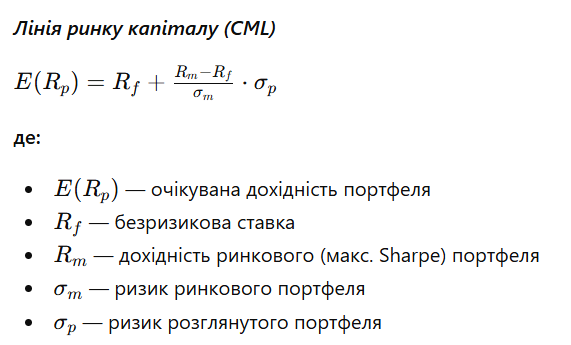

Лінія **CML** показує всі можливі оптимальні портфелі, які можна отримати, комбінуючи:

*   безризиковий актив (наприклад, облігації)
*   ринковий портфель (max Sharpe)



In [ ]:
risk_range = np.linspace(0, 0.5, 100)

cml = rf + (max_sharpe_portfolio['Return'] - rf) / max_sharpe_portfolio['Risk'] * risk_range


# **ПОБУДОВА ГРАФІКА EFFICIENT FRONTIER — PORTFOLIO ALLOCATION**

На представленому графіку відображається залежність між ризиком і дохідністю різних портфелів, а також ключові орієнтири для прийняття інвестиційних рішень.

**Кожна точка** — це окремий випадково згенерований портфель. **Колір точок** відображає **коефіцієнт Шарпа**. Чим вище та лівіше розташована точка — **тим ефективніший портфель**.

**Efficient Frontier (червона лінія)** показує найкращі портфелі при кожному рівні ризику. Вона формується як верхня межа хмари точок. Вище неї потрапити неможливо.

Інтерпретація:

*   більшість випадкових портфелів лежать нижче Efficient Frontier — ці портфелі не є оптимальними
*   лише невелика частина — оптимальні, які розташовані на Efficient Frontier

*   портфель з max Sharpe задає найкращу стратегію

Інвестор повинен прагнути до портфелів, розташованих на **Efficient Frontier** і, в ідеалі, використовувати комбінації вздовж **Capital Market Line** для досягнення максимальної дохідності на одиницю ризику.

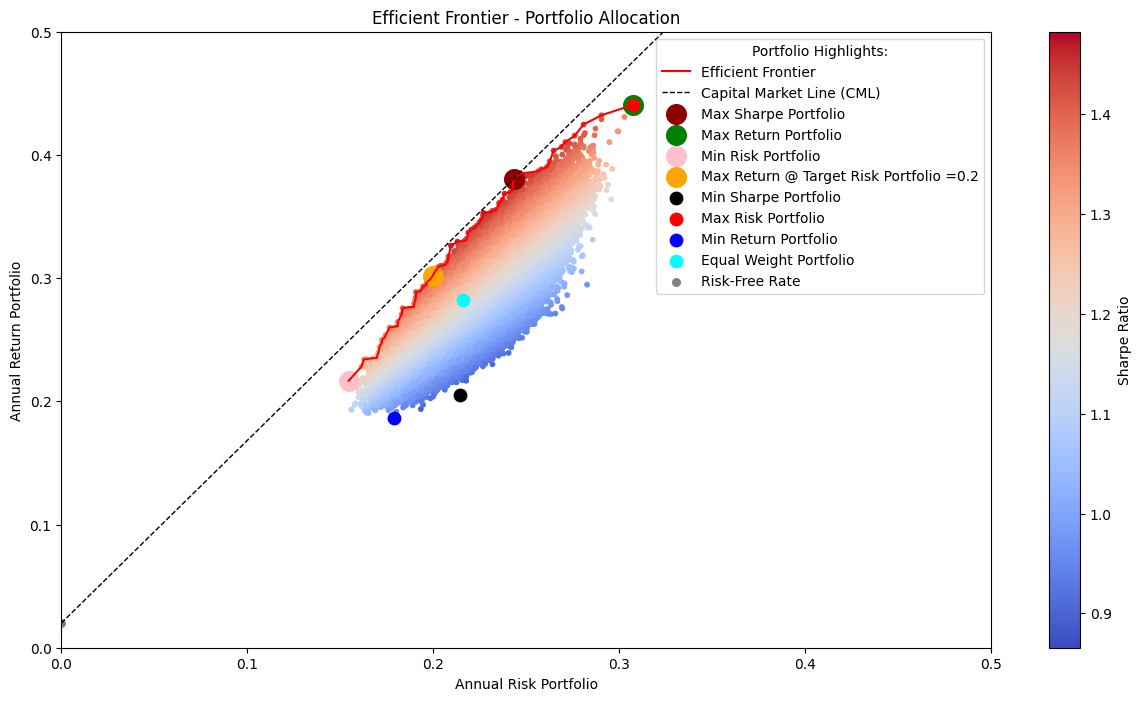

In [ ]:
plt.figure(figsize=(15, 8))

sc = plt.scatter(df_results['Risk'], df_results['Return'],c = df_results['Sharpe'],cmap = 'coolwarm' ,s=10)
plt.colorbar(sc, label='Sharpe Ratio')


plt.plot(
    frontier['Risk'],
    frontier['Return'],
    color='red',
    linewidth=1.5,
    label='Efficient Frontier'
)

plt.plot(risk_range, cml, color='black', linestyle='--', linewidth=1, label='Capital Market Line (CML)')


plt.scatter(
    max_sharpe_portfolio['Risk'], max_sharpe_portfolio['Return'],
    marker='o', s=200, label='Max Sharpe Portfolio',color='darkred'
)

plt.scatter(
    max_profit_portfolio['Risk'],
    max_profit_portfolio['Return'],
    marker='o',
    s=200,
    label='Max Return Portfolio',
    color='green'
)

plt.scatter(
    min_risk_portfolio['Risk'], min_risk_portfolio['Return'],
    marker='o', s=200, label='Min Risk Portfolio', color='pink'
)

plt.scatter(
    max_return_given_risk['Risk'], max_return_given_risk['Return'],
    marker='o', s=200, label=f"Max Return @ Target Risk Portfolio ={target_risk}",color='orange'
)

plt.scatter(
    min_sharpe_portfolio['Risk'], min_sharpe_portfolio['Return'],
    marker='o', s=80, label='Min Sharpe Portfolio',color='black'
)

plt.scatter(
    max_risk_portfolio['Risk'],
    max_risk_portfolio['Return'],
    marker='o',
    s=80,
    label='Max Risk Portfolio',
    color='red'
)

plt.scatter(
    min_profit_portfolio['Risk'],
    min_profit_portfolio['Return'],
    marker='o',
    s=80,
    label='Min Return Portfolio',
    color='blue'
)

plt.scatter (
    annual_portfolio_risk,
    annual_portfolio_return,
    marker='o',
    s=80,
    label='Equal Weight Portfolio',
    color='cyan'
)

plt.scatter(0,rf,color='gray',s=30,label='Risk-Free Rate')


plt.title('Efficient Frontier - Portfolio Allocation')
plt.xlabel('Annual Risk Portfolio')
plt.ylabel('Annual Return Portfolio')
plt.ylim(0,0.5)
plt.xlim(0,0.5)


plt.legend(title='Portfolio Highlights:')
plt.show()

# **УЗАГАЛЬНЮЮЧА ТАБЛИЦЯ ПОРТФЕЛІВ**

У цій таблиці представлені ваги активів для різних типів портфелів, а також їхні відповідні характеристики дохідності та ризику. Узагальнююча таблиця демонструє, що структура портфеля безпосередньо залежить від інвестиційної мети:

*   максимізація дохідності
*   мінімізація ризику

*   оптимізація за коефіцієнтом Шарпа





In [ ]:
print('======== Показатели портфеля с максимальным коэффициентом Шарпа ==========')
print(max_sharpe_portfolio.drop('Weights').to_string())


print('======== Показатели портфеля с минимальным коэффициентом Шарпа ===========')
print(min_sharpe_portfolio.drop('Weights').to_string())



print('========      Показатели портфеля максимальной доходности      ===========')
print(max_profit_portfolio.drop('Weights').to_string())


print('========      Показатели портфеля минимальной доходности      ============')
print(min_profit_portfolio.drop('Weights').to_string())


print('========      Показатели портфеля максимального риска         ============')
print(max_risk_portfolio.drop('Weights').to_string())


print('==========        Показатели портфеля минимального риска       ===========')
print(min_risk_portfolio.drop('Weights').to_string())


print(f"Показатели портфеля максимальной доходности при заданном уровне риска = {target_risk}")
print(max_return_given_risk.drop('Weights').to_string())



portfolio_allocation = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Max Sharpe': weights_ticker_max_sharpe['Weight'],
    'Min Sharpe': weights_ticker_min_sharpe['Weight'],
    'Max Return': weights_ticker_max_profit['Weight'],
    'Min Return': weights_ticker_min_profit['Weight'],
    'Max Risk': weights_ticker_max_risk['Weight'],
    'Min Risk': weights_ticker_min_risk['Weight'],
    'Max Return Given Risk': weights_ticker_max_return_given_risk['Weight'],
    'Annual Return': expected_return['Annual_Expected_Return'],
    'Daily Volatility': val_vol_returns['Daily_Volatility_Returns']


})
portfolio_allocation

======== Показатели портфеля с максимальным коэффициентом Шарпа ==========
Return    0.3807
Risk      0.2433
Sharpe    1.4825
======== Показатели портфеля с минимальным коэффициентом Шарпа ===========
Return    0.2054
Risk      0.2141
Sharpe    0.8656
========      Показатели портфеля максимальной доходности      ===========
Return    0.4407
Risk      0.3075
Sharpe    1.3682
========      Показатели портфеля минимальной доходности      ============
Return    0.1865
Risk      0.1787
Sharpe    0.9319
========      Показатели портфеля максимального риска         ============
Return    0.4407
Risk      0.3075
Sharpe    1.3682
==========        Показатели портфеля минимального риска       ===========
Return    0.2167
Risk      0.1545
Sharpe    1.2734
Показатели портфеля максимальной доходности при заданном уровне риска = 0.2
Return    0.3018
Risk      0.1997
Sharpe     1.411


,Ticker,Max Sharpe,Min Sharpe,Max Return,Min Return,Max Risk,Min Risk,Max Return Given Risk,Annual Return,Daily Volatility
0,AAPL,0.025359,0.074400,0.082392,0.032367,0.082392,0.034350,0.036834,0.276120,0.015195
1,AMZN,0.023400,0.215660,0.023032,0.109513,0.023032,0.028253,0.037033,0.219104,0.017152
2,BTC-USD,0.173074,0.033682,0.206289,0.021890,0.206289,0.065709,0.129100,0.700632,0.035158
3,GLD,0.180605,0.049390,0.023316,0.083709,0.023316,0.238482,0.195441,0.144412,0.007742
4,GOOGL,0.097488,0.026590,0.036945,0.029447,0.036945,0.088276,0.098180,0.235834,0.015079
5,JPM,0.086926,0.023100,0.078926,0.085449,0.078926,0.052149,0.157871,0.207633,0.014423
6,KO,0.043039,0.066882,0.020960,0.219353,0.020960,0.215529,0.079662,0.084868,0.009443
7,META,0.057979,0.210647,0.065137,0.132475,0.065137,0.035101,0.026596,0.205956,0.020139
8,MSFT,0.025451,0.020725,0.041748,0.032933,0.041748,0.040392,0.037932,0.259995,0.013995
9,NVDA,0.230234,0.024150,0.210220,0.028915,0.210220,0.065978,0.115724,0.727400,0.026111


# **РОЗБІР АКТИВІВ, ЩО ВХОДЯТЬ ДО ПОРТФЕЛІВ**

**ВИСОКОДОХІДНІ АКТИВИ:**

**BTC-USD** має високу вагу в портфелях (Max Sharpe, Max Return, Max Risk ≈ 20%) і забезпечує:

*   максимальну дохідність
*   але підвищує ризик

**NVDA** має високу вагу в портфелях (Max Sharpe, Max Return, Max Risk ≈ 20%) і є:

*  ключовим драйвером зростання

**TSLA** має підвищену вагу в ризикових портфелях і забезпечує:

*   високу дохідність
*   високу волатильність


**ЗАХИСНІ АКТИВИ:**

**GLD (золото)** має високу вагу в портфелях (Max Sharpe, Min Risk ≈ 20%) і виконує роль:

*   стабілізатора
*   знижує волатильність

**KO (Coca-Cola)** має високу вагу в портфелі (Min Risk ≈ 20%) і характеризується:

*   низькою дохідністю
*   низьким ризиком

**XOM** присутній у низькоризикових і збалансованих портфелях та додає:

*   диверсифікацію
*   стійкість


**ЗБАЛАНСОВАНІ АКТИВИ:**

**AAPL, MSFT, GOOGL** присутні майже в усіх портфелях і мають помірні ваги:

*   формують основу портфеля


**AMZN, META **— їхні ваги суттєво варіюються, використовуються як:

*   підсилювачі дохідності
*   але не завжди є обов’язковими


Ефективність портфеля визначається не окремими активами, а їх комбінацією: високодохідні активи підвищують прибутковість, захисні — знижують ризик, а збалансовані забезпечують стійкість структури.

# **РОЗРАХУНОК ОПТИМІЗАЦІЙНОГО ПОРТФЕЛЯ CML**

У цій частині було побудовано **портфель на Capital Market Line (CML)** з метою продемонструвати, що комбінація безризикового активу та оптимального ризикового портфеля дозволяє досягти тієї ж дохідності при меншому ризику.
Як цільову дохідність було обрано дохідність **портфеля мінімального ризику**, який знаходиться на ефективній границі.
Розраховано частку капіталу, що інвестується в: **тангенційний портфель** **(Max Sharpe Portfolio)**. Інша частина капіталу інвестується в: **безризиковий актив (risk-free asset)**

Ризик визначається лише через частку в ризиковому портфелі (**оскільки безризиковий актив має нульову волатильність**).
Підсумкова дохідність — це зважена комбінація:

*   ризикового портфеля
*   безризикового активу

Отриманий результат демонструє:
Портфель мінімального ризику (що складається лише з ризикових активів) є неефективним, якщо доступний безризиковий актив.
Використовуючи лінію ринку капіталу:

*   можна зберегти ту ж дохідність
*   але при цьому знизити ризик











In [ ]:
target_return_cml = min_risk_portfolio['Return']

tangenc_portfolio_weight = (target_return_cml - rf) / (max_sharpe_portfolio['Return'] - rf)
tangenc_portfolio_weight

asset_risk_free_weight = 1 - tangenc_portfolio_weight
asset_risk_free_weight

target_risk_cml = tangenc_portfolio_weight * max_sharpe_portfolio['Risk']
print(f"Риск оптимизационного портфеля CML = {target_risk_cml:.4f}")

return_cml = tangenc_portfolio_weight * max_sharpe_portfolio['Return'] + asset_risk_free_weight * rf
print(f"Доходность оптимизационного портфеля CML = {return_cml}")

target_cml_portfolio = pd.DataFrame({
    'Tangenc Portfolio Weight': [tangenc_portfolio_weight],
    'Risk Free Asset Weight': [asset_risk_free_weight]
})
target_cml_portfolio

Риск оптимизационного портфеля CML = 0.1327
Доходность оптимизационного портфеля CML = 0.2167


,Tangenc Portfolio Weight,Risk Free Asset Weight
0,0.545329,0.454671


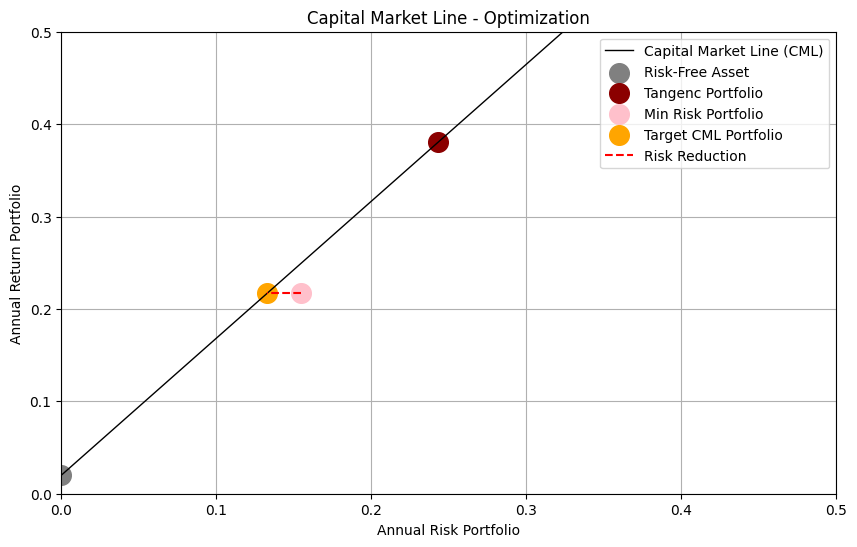

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(risk_range, cml, color='black', linestyle='-', linewidth=1, label='Capital Market Line (CML)')

plt.scatter(0,rf,color='gray',s=200,label='Risk-Free Asset')

plt.scatter(
    max_sharpe_portfolio['Risk'], max_sharpe_portfolio['Return'],
    marker='o', s=200, label='Tangenc Portfolio',color='darkred'
)

plt.scatter(
    min_risk_portfolio['Risk'], min_risk_portfolio['Return'],
    marker='o', s=200, label='Min Risk Portfolio', color='pink'
)

plt.scatter(
    target_risk_cml,
    return_cml,
    marker='o',
    s=200,
    label='Target CML Portfolio',
    color='orange'
)

plt.plot(
    [min_risk_portfolio['Risk'], target_risk_cml],
    [min_risk_portfolio['Return'], return_cml],
    color='red',
    linewidth=1.5,
    linestyle='--',
    label='Risk Reduction'
)




plt.title('Capital Market Line - Optimization')
plt.xlabel('Annual Risk Portfolio')
plt.ylabel('Annual Return Portfolio')
plt.legend()
plt.ylim(0,0.5)
plt.xlim(0,0.5)
plt.grid(True)


# **ВИСНОВОК ТА ЗАКЛЮЧЕННЯ**

З проєкту ми дізналися:

*   Ефективні портфелі лежать на ефективній границі, тобто ми знаходимо максимальну дохідність для будь-якого заданого рівня ризику.

*   Найбільш оптимальним є портфель із максимальним коефіцієнтом Шарпа, який має такі показники:

Return = 0.3807

Risk = 0.2433

Sharpe = 1.4825


*  Цей портфель є тангенційним — він знаходиться як на ефективній границі, так і на лінії ринку капіталу (CML), що робить його найефективнішим серед усіх 1 000 000 згенерованих портфелів.

*   Вибір портфеля залежить від цілей інвестора. Інвестор може використовувати будь-які портфелі, що лежать на ефективній границі. Наприклад, можна обрати захисний портфель мінімального ризику, який має такі показники:

Return = 0.2167

Risk = 0.1545

Sharpe = 1.2734


*   Цей портфель хоча й знаходиться на ефективній границі, але не лежить на лінії CML.


*   У такому випадку його слід змістити на цю лінію. Це досягається шляхом перерозподілу капіталу між тангенційним портфелем і безризиковим активом. Інвестувавши 54% капіталу в тангенційний портфель і 46% — у безризиковий актив, отримуємо портфель із такими показниками:

Return = 0.2167

Risk = 0.1327

Sharpe = 1.4825

*   Цей портфель лежить на лінії ринку капіталу, оскільки має такий самий коефіцієнт Шарпа (1.4825), як і тангенційний портфель. При цьому, маючи ту саму дохідність (0.1891), що й портфель мінімального ризику, його ризик знижується з 0.1545 до 0.1327.

Комбінація безризикового активу та портфеля з максимальним коефіцієнтом Шарпа домінує над будь-яким портфелем на ефективній границі. **Ефективний інвестор завжди знаходиться на прямій CML.**